In [ ]:
from google.colab import files
uploaded = files.upload()

Saving NIJ_s_Recidivism_Challenge_Full_Dataset_20240402 (1).zip to NIJ_s_Recidivism_Challenge_Full_Dataset_20240402 (1) (1).zip


In [ ]:
import zipfile
import os

zip_file = "NIJ_s_Recidivism_Challenge_Full_Dataset_20240402 (1).zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("recidivism_data")

print("Files extracted successfully!")

Files extracted successfully!


In [ ]:
os.listdir("recidivism_data")

['NIJ_s_Recidivism_Challenge_Full_Dataset_20240402.csv']

In [ ]:
import pandas as pd

df = pd.read_csv(
    "recidivism_data/NIJ_s_Recidivism_Challenge_Full_Dataset_20240402.csv"
)

df.head()

,ID,Gender,Race,Age_at_Release,Residence_PUMA,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,...,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years,Recidivism_Arrest_Year1,Recidivism_Arrest_Year2,Recidivism_Arrest_Year3,Training_Sample
0,1,M,BLACK,43-47,16,False,3.0,Standard,At least some college,3 or more,...,0.000000,0.0,0.488562,0.447610,False,False,False,False,False,1
1,2,M,BLACK,33-37,16,False,6.0,Specialized,Less than HS diploma,1,...,0.000000,0.0,0.425234,2.000000,False,True,False,False,True,1
2,3,M,BLACK,48 or older,24,False,7.0,High,At least some college,3 or more,...,0.166667,0.0,0.000000,0.000000,False,True,False,True,False,1
3,4,M,WHITE,38-42,16,False,7.0,High,Less than HS diploma,1,...,0.000000,0.0,1.000000,0.718996,False,False,False,False,False,1
4,5,M,WHITE,33-37,16,False,4.0,Specialized,Less than HS diploma,3 or more,...,0.058824,0.0,0.203562,0.929389,False,True,True,False,False,1


In [ ]:
df.shape

(25835, 54)

In [ ]:
df.columns

Index(['ID', 'Gender', 'Race', 'Age_at_Release', 'Residence_PUMA',
       'Gang_Affiliated', 'Supervision_Risk_Score_First',
       'Supervision_Level_First', 'Education_Level', 'Dependents',
       'Prison_Offense', 'Prison_Years', 'Prior_Arrest_Episodes_Felony',
       'Prior_Arrest_Episodes_Misd', 'Prior_Arrest_Episodes_Violent',
       'Prior_Arrest_Episodes_Property', 'Prior_Arrest_Episodes_Drug',
       'Prior_Arrest_Episodes_PPViolationCharges',
       'Prior_Arrest_Episodes_DVCharges', 'Prior_Arrest_Episodes_GunCharges',
       'Prior_Conviction_Episodes_Felony', 'Prior_Conviction_Episodes_Misd',
       'Prior_Conviction_Episodes_Viol', 'Prior_Conviction_Episodes_Prop',
       'Prior_Conviction_Episodes_Drug',
       'Prior_Conviction_Episodes_PPViolationCharges',
       'Prior_Conviction_Episodes_DomesticViolenceCharges',
       'Prior_Conviction_Episodes_GunCharges', 'Prior_Revocations_Parole',
       'Prior_Revocations_Probation', 'Condition_MH_SA', 'Condition_Cog_Ed',
     

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25835 entries, 0 to 25834
Data columns (total 54 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   ID                                                 25835 non-null  int64  
 1   Gender                                             25835 non-null  object 
 2   Race                                               25835 non-null  object 
 3   Age_at_Release                                     25835 non-null  object 
 4   Residence_PUMA                                     25835 non-null  int64  
 5   Gang_Affiliated                                    22668 non-null  object 
 6   Supervision_Risk_Score_First                       25360 non-null  float64
 7   Supervision_Level_First                            24115 non-null  object 
 8   Education_Level                                    25835 non-null  object 
 9   Depend

In [ ]:
df.columns.tolist()

['ID',
 'Gender',
 'Race',
 'Age_at_Release',
 'Residence_PUMA',
 'Gang_Affiliated',
 'Supervision_Risk_Score_First',
 'Supervision_Level_First',
 'Education_Level',
 'Dependents',
 'Prison_Offense',
 'Prison_Years',
 'Prior_Arrest_Episodes_Felony',
 'Prior_Arrest_Episodes_Misd',
 'Prior_Arrest_Episodes_Violent',
 'Prior_Arrest_Episodes_Property',
 'Prior_Arrest_Episodes_Drug',
 'Prior_Arrest_Episodes_PPViolationCharges',
 'Prior_Arrest_Episodes_DVCharges',
 'Prior_Arrest_Episodes_GunCharges',
 'Prior_Conviction_Episodes_Felony',
 'Prior_Conviction_Episodes_Misd',
 'Prior_Conviction_Episodes_Viol',
 'Prior_Conviction_Episodes_Prop',
 'Prior_Conviction_Episodes_Drug',
 'Prior_Conviction_Episodes_PPViolationCharges',
 'Prior_Conviction_Episodes_DomesticViolenceCharges',
 'Prior_Conviction_Episodes_GunCharges',
 'Prior_Revocations_Parole',
 'Prior_Revocations_Probation',
 'Condition_MH_SA',
 'Condition_Cog_Ed',
 'Condition_Other',
 'Violations_ElectronicMonitoring',
 'Violations_Instructi

In [ ]:
target = "Recidivism_Within_3years"

print(df[target].value_counts())

Recidivism_Within_3years
True     14904
False    10931
Name: count, dtype: int64


In [ ]:
drop_columns = [
    "ID",
    "Recidivism_Arrest_Year1",
    "Recidivism_Arrest_Year2",
    "Recidivism_Arrest_Year3",
    "Training_Sample"
]

df = df.drop(columns=drop_columns)

print(df.shape)

(25835, 49)


In [ ]:
X = df.drop("Recidivism_Within_3years", axis=1)
y = df["Recidivism_Within_3years"]

print(X.shape)
print(y.shape)

(25835, 48)
(25835,)


In [ ]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(25835, 114)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(20668, 114)
(5167, 114)


In [ ]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7261467002128895
Precision: 0.7431930693069307
Recall: 0.8041513223970539
F1 Score: 0.7724714584338318


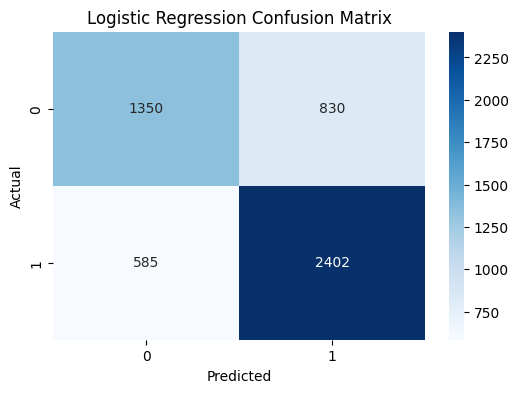

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
nn_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = nn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6374 - loss: 0.7033 - val_accuracy: 0.6824 - val_loss: 0.6023
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6891 - loss: 0.5924 - val_accuracy: 0.7182 - val_loss: 0.5610
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7022 - loss: 0.5759 - val_accuracy: 0.7017 - val_loss: 0.5811
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7064 - loss: 0.5721 - val_accuracy: 0.6792 - val_loss: 0.6020
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7145 - loss: 0.5564 - val_accuracy: 0.7165 - val_loss: 0.5679
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7267 - loss: 0.5466 - val_accuracy: 0.7199 - val_loss: 0.5511
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7251 - loss: 0.5459 - val_accuracy: 0.7240 - val_loss: 0.5484
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7307 - loss: 0.5370 - val_accuracy: 0.

In [ ]:
nn_loss, nn_accuracy = nn_model.evaluate(X_test, y_test)

print("Neural Network Accuracy:", nn_accuracy)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7238 - loss: 0.5530
Neural Network Accuracy: 0.7238242626190186


In [ ]:
nn_pred = (nn_model.predict(X_test) > 0.5).astype("int32")

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print("NN Precision:", precision_score(y_test, nn_pred))
print("NN Recall:", recall_score(y_test, nn_pred))
print("NN F1:", f1_score(y_test, nn_pred))

NN Precision: 0.7322811197141156
NN Recall: 0.8232340140609307
NN F1: 0.7750985027580772


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [ ]:
X_train_shap = X_train.apply(pd.to_numeric, errors="coerce").fillna(0)
X_test_shap = X_test.apply(pd.to_numeric, errors="coerce").fillna(0)

In [ ]:
import shap
import numpy as np

X_sample = X_test_shap.sample(100, random_state=42)

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_sample)

print(np.array(shap_values).shape)

(100, 114, 2)


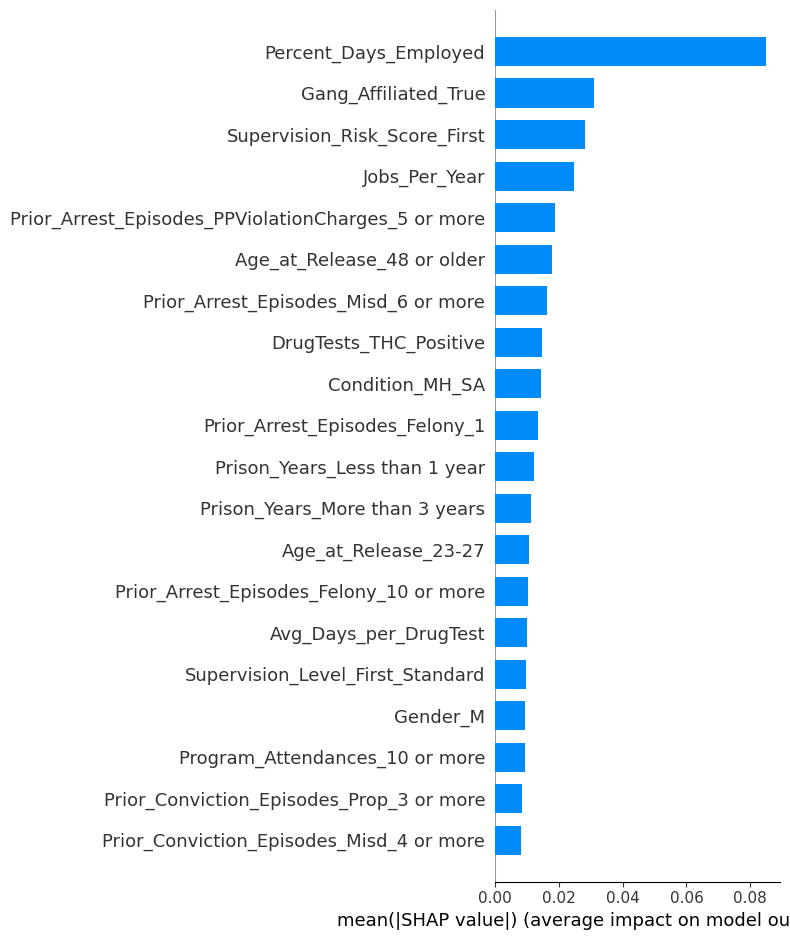

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample,
    plot_type="bar"
)

In [ ]:
!pip install fairlearn

In [ ]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score

fairness = MetricFrame(
    metrics=accuracy_score,
    y_true=y_test,
    y_pred=rf_pred,
    sensitive_features=df.loc[y_test.index, "Race"]
)

print(fairness.by_group)

Race
BLACK    0.719022
WHITE    0.740486
Name: accuracy_score, dtype: float64
